<a href="https://colab.research.google.com/github/LoPA607/IE643/blob/main/oneshot2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run this first (one cell). These libs are stable and won't cause version import errors.
!pip install -q torch torchvision pillow tqdm git+https://github.com/openai/CLIP.git lpips scikit-image kornia


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00


In [ ]:
!pip install sympy==1.12


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 83.8 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.3
    Uninstalling sympy-1.13.3:
      Successfully uninstalled sympy-1.13.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.8.0+cu126 requires sympy>=1.13.3, but you have sympy 1.12 which is incompatible.


In [ ]:
!pip install -q torch torchvision pillow tqdm git+https://github.com/openai/CLIP.git lpips kornia scikit-image

import os
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torchvision.utils import save_image
import clip
import lpips

# -------------------------
# Config / Hyperparameters
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 256
EPOCHS = 6000
LR = 1e-5                 # reduced for stability
CLIP_WEIGHT = 1.0         # small weight to prevent explosion
LPIPS_WEIGHT = 0.5
STRUCT_WEIGHT = 0.5
STYLE_GRAM_WEIGHT = 1.0
GRAD_CLIP = 0.5
WARMUP_EPOCHS = 20         # train only LPIPS + structure

STYLE_IMAGE = "/content/drive/MyDrive/Colab Notebooks/IE643 Course Project/style3.png"
CONTENT_IMAGE = "/content/drive/MyDrive/Colab Notebooks/IE643 Course Project/clean2.jpg"
NEW_CONTENT = "new_content.jpg"  # optional inference

# -------------------------
# Utilities
# -------------------------
to_tensor = transforms.Compose([transforms.ToTensor()])
to_pil = transforms.ToPILImage()

def load_image(path, size=IMG_SIZE):
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size), Image.LANCZOS)
    return img

def tensor01(img_tensor):
    return img_tensor.clamp(0,1)

def tensor_to_pil_img(tensor):
    return to_pil(tensor.detach().cpu().squeeze(0))

# -------------------------
# Models
# -------------------------
class VGGEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        self.features = nn.Sequential(*list(vgg.children())[:21])  # up to relu4_2
        for p in self.features.parameters():
            p.requires_grad = False
    def forward(self, x):
        return self.features(x)

class Decoder(nn.Module):
    def __init__(self, in_ch=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 256, 3, padding=1), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 3, 3, padding=1),
            nn.Sigmoid()
        )
    def forward(self, z):
        return self.net(z)

class SPN(nn.Module):
    def __init__(self, ch=512, struct_ch=1, hidden=256):
        super().__init__()
        self.conv1 = nn.Conv2d(ch + struct_ch, hidden, 3, padding=1)
        self.conv2 = nn.Conv2d(hidden, hidden, 3, padding=1)
        self.conv3 = nn.Conv2d(hidden, ch, 3, padding=1)
        self.act = nn.ReLU(True)
    def forward(self, feat, struct):
        x = torch.cat([feat, struct], dim=1)
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        res = self.conv3(x)
        return res

# Instantiate
encoder = VGGEncoder().to(DEVICE)
decoder = Decoder().to(DEVICE)
spn = SPN().to(DEVICE)
optim = torch.optim.Adam(list(decoder.parameters()) + list(spn.parameters()), lr=LR)

# LPIPS perceptual loss
lpips_v = lpips.LPIPS(net='vgg').to(DEVICE)

# CLIP
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model.eval()

# ImageNet normalization for Gram loss
imagenet_mean = torch.tensor([0.485,0.456,0.406], device=DEVICE).view(1,3,1,1)
imagenet_std  = torch.tensor([0.229,0.224,0.225], device=DEVICE).view(1,3,1,1)

# -------------------------
# Loss functions
# -------------------------
def structure_loss(output, target):
    grad_o_x = torch.abs(output[:, :, :, 1:] - output[:, :, :, :-1])
    grad_t_x = torch.abs(target[:, :, :, 1:] - target[:, :, :, :-1])
    grad_o_y = torch.abs(output[:, :, 1:, :] - output[:, :, :-1, :])
    grad_t_y = torch.abs(target[:, :, 1:, :] - target[:, :, :-1, :])
    return F.l1_loss(grad_o_x, grad_t_x) + F.l1_loss(grad_o_y, grad_t_y)

def gram_matrix(feat):
    b, c, h, w = feat.shape
    f = feat.view(b, c, -1)
    G = torch.bmm(f, f.transpose(1,2)) / (c * h * w)
    return G

def directional_clip_loss(content_pil, style_pil, output_pil):
    c = clip_preprocess(content_pil).unsqueeze(0).to(DEVICE)
    s = clip_preprocess(style_pil).unsqueeze(0).to(DEVICE)
    o = clip_preprocess(output_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        fc = clip_model.encode_image(c)
        fs = clip_model.encode_image(s)
    fo = clip_model.encode_image(o)
    fc = fc / fc.norm(dim=-1, keepdim=True)
    fs = fs / fs.norm(dim=-1, keepdim=True)
    fo = fo / fo.norm(dim=-1, keepdim=True)
    dir_ref = (fs - fc)
    dir_out = (fo - fc)
    dir_ref = dir_ref / (dir_ref.norm(dim=-1, keepdim=True)+1e-8)
    dir_out = dir_out / (dir_out.norm(dim=-1, keepdim=True)+1e-8)
    return torch.clamp(1.0 - F.cosine_similarity(dir_ref, dir_out, dim=-1).mean(), 0, 1.0)

def extract_structure_from_pil(pil_img, feat_hw):
    gray = pil_img.convert("L").resize((IMG_SIZE, IMG_SIZE))
    t = to_tensor(gray).unsqueeze(0).to(DEVICE).float()
    kernel = torch.tensor([[0,-1,0],[-1,4,-1],[0,-1,0]], device=DEVICE).view(1,1,3,3).float()
    edge = F.conv2d(t, kernel, padding=1)
    edge = torch.tanh(edge)
    edge_ds = F.interpolate(edge, size=feat_hw, mode='bilinear', align_corners=False)
    return edge_ds

# -------------------------
# Load images
# -------------------------
style_pil = load_image(STYLE_IMAGE)
content_pil = load_image(CONTENT_IMAGE)
style_t = to_tensor(style_pil).unsqueeze(0).to(DEVICE).float()
content_t = to_tensor(content_pil).unsqueeze(0).to(DEVICE).float()

feat_hw = (encoder(content_t).shape[2], encoder(content_t).shape[3])
struct_content = extract_structure_from_pil(content_pil, feat_hw)

# Precompute CLIP embeddings
with torch.no_grad():
    clip_style = clip_model.encode_image(clip_preprocess(style_pil).unsqueeze(0).to(DEVICE))
    clip_style = clip_style / clip_style.norm(dim=-1, keepdim=True)

# -------------------------
# Training loop
# -------------------------
print("Starting one-shot fine-tuning... DEVICE =", DEVICE)
best_loss = 1e9

for epoch in range(1, EPOCHS+1):
    decoder.train(); spn.train()
    optim.zero_grad()

    with torch.no_grad():
        feat = encoder(content_t)

    # Scale SPN output early to prevent explosions
    res = spn(feat, struct_content) * 0.1
    feat_mod = feat + res
    out = decoder(feat_mod)
    out = tensor01(out)

    # LPIPS + structure
    loss_lpips = lpips_v(out, content_t).mean()
    loss_str = structure_loss(out, content_t)
    out_pil = tensor_to_pil_img(out)

    # CLIP directional loss only after warmup
    if epoch > WARMUP_EPOCHS:
        loss_clip_dir = directional_clip_loss(content_pil, style_pil, out_pil)
    else:
        loss_clip_dir = torch.tensor(0.0, device=DEVICE)

    # Style Gram loss with normalization
    with torch.no_grad():
# Style Gram loss without normalizing features
        feat_out = encoder(out)
        feat_style = encoder(style_t)
        loss_gram = F.mse_loss(gram_matrix(feat_out), gram_matrix(feat_style))


    # Total loss
    loss = (LPIPS_WEIGHT * loss_lpips +
            STRUCT_WEIGHT * loss_str +
            CLIP_WEIGHT * loss_clip_dir +
            STYLE_GRAM_WEIGHT * loss_gram)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(list(decoder.parameters()) + list(spn.parameters()), GRAD_CLIP)
    optim.step()

    if epoch % 5 == 0 or epoch==1:
        print(f"Epoch {epoch}/{EPOCHS} | Total {loss.item():.4f} | LPIPS {loss_lpips.item():.4f} | Struct {loss_str.item():.4f} | DirCLIP {loss_clip_dir.item():.4f} | Gram {loss_gram.item():.4f}")
        save_image(out, f"stylized_epoch_{epoch}.png")

    if loss.item() < best_loss:
        best_loss = loss.item()
        torch.save({'decoder': decoder.state_dict(), 'spn': spn.state_dict()}, "best_spn_decoder.pth")

print("Fine-tuning done. Best loss:", best_loss)

# -------------------------
# Optional inference on new content
# -------------------------
if os.path.exists(NEW_CONTENT):
    new_pil = load_image(NEW_CONTENT)
    new_t = to_tensor(new_pil).unsqueeze(0).to(DEVICE).float()
    with torch.no_grad():
        feat_new = encoder(new_t)
        feat_new_mod = feat_new + spn(feat_new, extract_structure_from_pil(new_pil, feat_hw)) * 0.1
        out_new = decoder(feat_new_mod)
        out_new = tensor01(out_new)
    save_image(out_new, "stylized_new_content.png")
    print("Saved stylized_new_content.png")


  Preparing metadata (setup.py) ... done
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Starting one-shot fine-tuning... DEVICE = cuda
Epoch 1/6000 | Total 0.3828 | LPIPS 0.6870 | Struct 0.0785 | DirCLIP 0.0000 | Gram 0.0000
Epoch 5/6000 | Total 0.3745 | LPIPS 0.6704 | Struct 0.0785 | DirCLIP 0.0000 | Gram 0.0000
Epoch 10/6000 | Total 0.3676 | LPIPS 0.6569 | Struct 0.0784 | DirCLIP 0.0000 | Gram 0.0000
Epoch 15/6000 | Total 0.3622 | LPIPS 0.6462 | Struct 0.0782 | DirCLIP 0.0000 | Gram 0.0000
Epoch 20/6000 | Total 0.3573 | LPIPS 0.6365 | Struct 0.0780 | DirCLIP 0.0000 | Gram 0.0000
Epoch 25/6000 | Total 0.8245 | LPIPS 0.6269 | Struct 0.0778 | DirCLIP 0.4722 | Gram 0.0000
Epoch 30/6000 | Total 0.8280 | LPIPS 0.6155 | Struct 0.0775 | DirCLIP 0.4814 | Gram 0.0000
Epoch 35/6000 | Total 0.8251 | LPIPS 0.6012 | Struct 0.0773 | DirCLIP 0.4858 | Gram 0.0000
Epoch 40/6000 | Total 0.8314

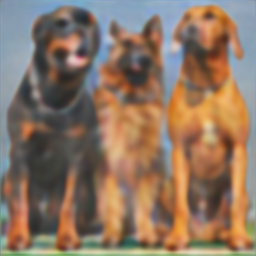

In [ ]:
from IPython.display import Image, display

final_image_path = "stylized_epoch_600.png"
if os.path.exists(final_image_path):
    display(Image(filename=final_image_path))
else:
    print(f"Final image not found at {final_image_path}")